In [7]:
import sys
from pathlib import Path
# Add parent directory to path to import from src/
sys.path.append(str(Path(__file__).parent.parent) if '__file__' in globals() else str(Path.cwd().parent))

from sionna.rt import load_scene, RadioMapSolver, PathSolver, Camera, transform_mesh, MeshRadioMap, PlanarRadioMap, Receiver
from src.utils import extract_building_positions_from_scene, get_antenna_positions, get_scene_bounds, get_tx_color, get_building_bounds, clip_terrain_to_buildings
from src.base_station import set_tx_antenna_array, add_base_station
from src.user_equipment import set_rx_antenna_array, generate_ue_parameters
import numpy as np

In [22]:
# Define parameters
NUM_DEPLOYMENT_BUILDINGS = 3  # number of buildings to deploy base stations on
ANTENNA_HEIGHT_OFFSET = 10.0  # height offset of antennas from the roof
SCENE_CENTER = [0.0, 0.0]  # center of the scene
USER_SHIFT_FROM_GROUND = 1.5  # up shift in meters of users from the ground plane or ground mesh
CLIP_TERRAIN_TO_BUILDINGS = True  # whether to clip terrain to building bounds
TERRAIN_CLIP_MARGIN = 10.0  # margin in meters around buildings when clipping terrain
OUTPUT_DIR_NAME = Path("output")  # directory to save the output files
scene_dir = Path("../scenes/boston_1/")  # path to the scene directory
scene_xml_path = scene_dir / "scene.xml"  # path to the scene XML file
output_dir = OUTPUT_DIR_NAME / scene_dir.name
output_dir.mkdir(parents=True, exist_ok=True)

# TX antenna array parameters
TX_NUM_ROWS = 8  # number of rows of antennas
TX_NUM_COLS = 8  # number of columns of antennas
TX_VERTICAL_SPACING = 0.5  # vertical spacing (in units of carrier wavelength) between antennas
TX_HORIZONTAL_SPACING = 0.5  # horizontal spacing (in units of carrier wavelength) between antennas
TX_PATTERN = "tr38901"  # tx antenna pattern
TX_POLARIZATION = "cross"  # polarization of the tx antennas


# Base station parameters
NUM_SECTORS = 6  # number of sectors for each base station
MECHANICAL_TILT = 10.0  # mechanical tilt of the antenna
AZIMUTH_OFFSET = 0.0  # rotate the antenna arrays around z-axis by this amount (in degrees)
TX_POWER_DBM = 43.0  # tx power in dBm for each tx antenna array
BS_DISPLAY_RADIUS = 15.0  # display radius of the sphere representing the base station when visualized


# RX antenna array parameters
RX_NUM_ROWS = 1  # number of rows of antennas
RX_NUM_COLS = 1  # number of columns of antennas
RX_DISPLAY_RADIUS = 3  # display radius of the sphere representing the receiver when visualized
RX_VERTICAL_SPACING = 0.5  # vertical spacing (in units of carrier wavelength) between antennas
RX_HORIZONTAL_SPACING = 0.5  # horizontal spacing (in units of carrier wavelength) between antennas
RX_PATTERN = "iso"  # rx antenna pattern
RX_POLARIZATION = "VH"  # polarization of the rx antennas


# Radio map solver parameters
RADIO_MAP_DIFFUSE_REFLECTION = True  # whether to include diffuse reflection
RADIO_MAP_DIFFRACTION = True  # whether to include diffraction
RADIO_MAP_EDGE_DIFFRACTION = True  # whether to include edge diffraction
RADIO_MAP_MAX_DEPTH = 5  # maximum number of ray scene interactions
RADIO_MAP_SAMPLES_PER_TX = 10**8  # number of samples per tx antenna array

# Path solver parameters
PATH_SOLVER_MAX_DEPTH = 5  # maximum number of ray scene interactions
PATH_SOLVER_MAX_NUM_PATHS_PER_SRC = 10**6  # maximum number of paths per source
PATH_SOLVER_SAMPLES_PER_SRC = 10**6  # number of samples per source
PATH_SOLVER_SYNTHETIC_ARRAY = True  # use synthetic array for path computation
PATH_SOLVER_LOS_MODE = True  # include line-of-sight paths
PATH_SOLVER_SPECULAR_REFLECTION = True  # include specular reflections
PATH_SOLVER_DIFFUSE_REFLECTION = False  # include diffuse reflections
PATH_SOLVER_REFRACTION = False  # include refraction
PATH_SOLVER_DIFFRACTION = True  # include diffraction
PATH_SOLVER_EDGE_DIFFRACTION = False  # include edge diffraction
PATH_SOLVER_DIFFRACTION_LIT_REGION = False  # include diffraction in lit region
PATH_SOLVER_SEED = 1  # seed for reproducibility

# user sampling parameters
NUM_USER_SAMPLES_PER_TX = 100  # number of user samples to generate
USER_SAMPLE_SEED = 1  # seed for the user sampling
USER_SAMPLE_MIN_VAL_DB = -150  # minimum value in dB for the user sampling
USER_SAMPLE_METRIC = "path_gain"  # metric for the user sampling
TX_ASSOCIATION = True  # whether to use tx association for the user sampling
SAMPLE_CENTER_POS = True  # whether sample the user sampling from the radio map cell center, if True, the user is located at the center of the cell

# User equipment mobility presets
# Each preset defines: orientation_mode, speed_distribution, direction_mode, and optional speed params
MOBILITY_PRESETS = {
    "stationary": {
        "orientation_mode": "random",  # "random" or "to_tx"
        "speed_distribution": None,
    },
    "stationary_to_tx": {
        "orientation_mode": "to_tx",
        "speed_distribution": None,
    },
    "pedestrian": {
        "orientation_mode": "random",
        "speed_distribution": "pedestrian",  # 0.5-2 m/s
        "direction_mode": "random",
    },
    "pedestrian_to_tx": {
        "orientation_mode": "to_tx",
        "speed_distribution": "pedestrian",
        "direction_mode": "random",
    },
    "vehicular": {
        "orientation_mode": "random",
        "speed_distribution": "vehicular",  # 8-30 m/s
        "direction_mode": "random",
    },
    "slow_walking": {
        "orientation_mode": "random",
        "speed_distribution": "uniform_continuous",
        "speed_min": 0.5,
        "speed_max": 1.5,
        "direction_mode": "random",
    },
    "fast_walking": {
        "orientation_mode": "random",
        "speed_distribution": "uniform_continuous",
        "speed_min": 1.5,
        "speed_max": 2.5,
        "direction_mode": "random",
    },
}
MOBILITY_PRESET = "stationary"  # select preset to use

In [9]:
# merge_shapes=False prevents the building walls and roofs from being merged into a single object
scene = load_scene(scene_xml_path, merge_shapes=False) 

# get the bounding box of the scene
# used to position the camera only
_, bbox_max = get_scene_bounds(scene)

# Detect if elevation data is present by checking the lidar_terrain.ply file
lidar_terrain_path = scene_dir / "mesh" / "lidar_terrain.ply"  # this file does not exist if lidar elevation data is not present
has_elevation = lidar_terrain_path.exists()

# Extract building positions from the loaded scene object (needed for clipping and antenna placement)
building_positions = extract_building_positions_from_scene(scene)

# Optionally clip terrain to building bounds BEFORE creating measurement surface
if CLIP_TERRAIN_TO_BUILDINGS and has_elevation:
    bounds = get_building_bounds(building_positions)
    if bounds:
        (min_x, min_y), (max_x, max_y) = bounds
        print(f"Building bounds: x=[{min_x:.1f}, {max_x:.1f}], y=[{min_y:.1f}, {max_y:.1f}]")
        clip_terrain_to_buildings(scene, building_positions, margin=TERRAIN_CLIP_MARGIN)

# Now create measurement surface from (potentially clipped) terrain
if has_elevation:
    terrain_obj = scene.objects.get("ground")
    if terrain_obj:
        measurement_surface = terrain_obj.clone(as_mesh=True)
        transform_mesh(measurement_surface, translation=[0,0,USER_SHIFT_FROM_GROUND])
    else:
        measurement_surface = None
else:
    measurement_surface = None

# get the antenna positions for deployment buildings
antenna_information = get_antenna_positions(
    building_positions, 
    scene_center=SCENE_CENTER,
    antenna_height_offset=ANTENNA_HEIGHT_OFFSET,
    num_deployment_buildings=NUM_DEPLOYMENT_BUILDINGS)

2026-01-18 00:42:31 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Building bounds: x=[-478.0, 388.1], y=[-399.2, 378.4]
Clipped terrain: clamped 65380/212084 vertices to bounds
  Bounds: x=[-488.0, 398.1], y=[-409.2, 388.4]


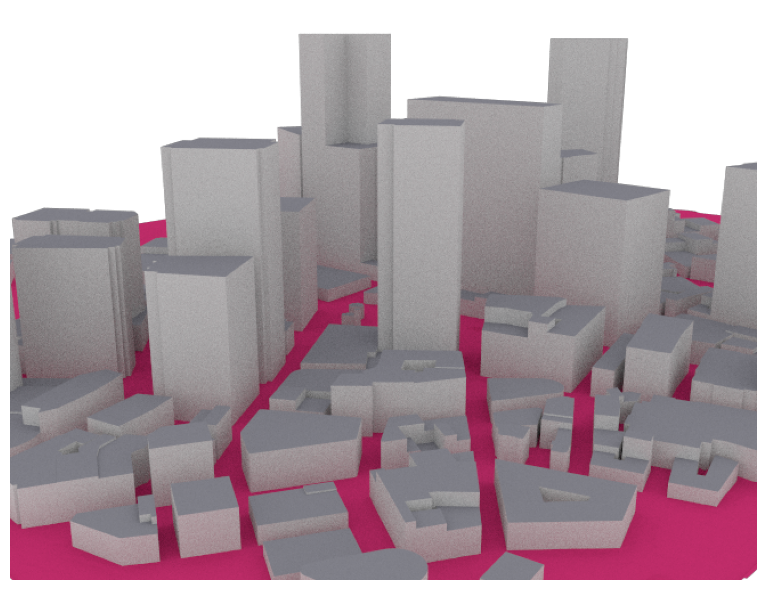

In [10]:
# Position the camera at a good viewing distance from the scene center and look at the scene center
camera = Camera(position=bbox_max, look_at=[0, 0, 0])
scene.render(camera=camera);
# it might be a good idea to save the scene picture for debugging purposes
_ = scene.render_to_file(filename=f"{output_dir}/scene.png", camera=camera)

In [11]:
# set tx and rx specs and add base stations
set_tx_antenna_array(
    scene,
    num_rows=TX_NUM_ROWS,
    num_cols=TX_NUM_COLS,
    vertical_spacing=TX_VERTICAL_SPACING,
    horizontal_spacing=TX_HORIZONTAL_SPACING,
    pattern=TX_PATTERN,
    polarization=TX_POLARIZATION)

# For radio map solver, receive antenna array params are assumed fixed
# and modifying them does not matter. See below from the Sionna RT technical report:
# The receive antenna pattern is not applied here. Instead, the squared norm of the
# electric field is used. This is equivalent to assuming that a receiver positioned
# on the measurement plane uses a dual-polarized isotropic antenna, and that both components are combined non-coherently.
# Therefore, the following line is needed for Path Solver not Radio Map Solver
set_rx_antenna_array(
    scene,
    num_rows=RX_NUM_ROWS,
    num_cols=RX_NUM_COLS,
    vertical_spacing=RX_VERTICAL_SPACING,
    horizontal_spacing=RX_HORIZONTAL_SPACING,
    pattern=RX_PATTERN,
    polarization=RX_POLARIZATION
)

# add base stations
for i, current_antenna_information in enumerate(antenna_information):
    bs_name = f"BS_{i}"
    _, antenna_position = current_antenna_information
    print(f"Adding base station {bs_name} at position {antenna_position}")
    add_base_station(
        scene,
        bs_name,
        position=antenna_position,
        num_sectors=NUM_SECTORS,
        mechanical_tilt=MECHANICAL_TILT,
        azimuth_offset=AZIMUTH_OFFSET,
        tx_power_dbm=TX_POWER_DBM,
        display_radius=BS_DISPLAY_RADIUS
    )

Antenna Array Configuration Set:
  - Array: 8x8 (128 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [15.3]°
UE Antenna Array Configuration Set:
  - Array: 1x1 (2 elements)
  - Pattern: iso, Polarization: VH
  - Spacing: V=0.5λ, H=0.5λ
Adding base station BS_0 at position [-55.30364227294922, -73.86759948730469, 220.5]
Added BS_0_sector_1 at position [[-55.3036, -73.8676, 220.5]], azimuth 0.0°
Added BS_0_sector_2 at position [[-55.3036, -73.8676, 220.5]], azimuth 60.0°
Added BS_0_sector_3 at position [[-55.3036, -73.8676, 220.5]], azimuth 120.0°
Added BS_0_sector_4 at position [[-55.3036, -73.8676, 220.5]], azimuth 180.0°
Added BS_0_sector_5 at position [[-55.3036, -73.8676, 220.5]], azimuth 240.0°
Added BS_0_sector_6 at position [[-55.3036, -73.8676, 220.5]], azimuth 300.0°

Base Station 'BS_0' Summary:
  - Sectors: 6
  - Mechanical tilt: 10.0°
  - TX Power: 43.0 dBm
  - Position: [[-55.3036], [-73.8676], [220.5]] m
Adding base 

In [12]:
rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               measurement_surface=measurement_surface,
               diffuse_reflection=RADIO_MAP_DIFFUSE_REFLECTION,
               diffraction=RADIO_MAP_DIFFRACTION,
               edge_diffraction=RADIO_MAP_EDGE_DIFFRACTION,
               max_depth=RADIO_MAP_MAX_DEPTH,
               samples_per_tx=RADIO_MAP_SAMPLES_PER_TX)

In [13]:
if isinstance(rm, MeshRadioMap):
    scene.preview(radio_map=rm, rm_db_scale=True, rm_metric="path_gain");

In [14]:
if isinstance(rm, PlanarRadioMap):
    rm.show(metric="path_gain", tx=0);

In [15]:
tx_association = rm.tx_association(metric="path_gain").numpy()
valid_association_mask = tx_association != -1
print(f"Percentage of cells with coverage: {np.sum(valid_association_mask) / len(valid_association_mask) * 100:.2f}%")

Percentage of cells with coverage: 73.80%


In [16]:
sampled_positions = rm.sample_positions(
    num_pos=NUM_USER_SAMPLES_PER_TX,
    metric=USER_SAMPLE_METRIC,
    min_val_db=USER_SAMPLE_MIN_VAL_DB,
    tx_association=TX_ASSOCIATION,
    center_pos=SAMPLE_CENTER_POS,
    seed=USER_SAMPLE_SEED
)

In [17]:
# first index for the positions vs. cell id
# second index for the tx id
# third index for the position id
print(sampled_positions[0][0][0]) # print the position of the tx=0, user=0 for that tx.
print(sampled_positions[1][0][0]) # print the cell_id of the tx=0, user=0 for that tx.

[398.089, 101.085, 1.60333]
63924


In [18]:
# sampled_positions[0] = positions tensor [num_tx, num_users_per_tx, 3]
# sampled_positions[1] = cell_ids tensor [num_tx, num_users_per_tx]
# Convert to numpy once for efficient iteration
positions = sampled_positions[0].numpy()  # shape: [num_tx, num_users_per_tx, 3]
cell_ids = sampled_positions[1].numpy()   # shape: [num_tx, num_users_per_tx]

num_txs, num_users_per_tx, _ = positions.shape
total_users = num_txs * num_users_per_tx
print(f"Total TXs: {num_txs}, Users per TX: {num_users_per_tx}, Total users: {total_users}")

# Get config from selected preset and generate UE parameters
preset_config = MOBILITY_PRESETS[MOBILITY_PRESET]
orientation_mode = preset_config.get("orientation_mode", "random")

orientations, velocities = generate_ue_parameters(
    num_ues=total_users,
    seed=USER_SAMPLE_SEED,
    **preset_config
)

# Add receivers for each user
user_count = 0
for tx_idx in range(num_txs):
    # Map tx_idx to TX name: BS_{bs_id}_sector_{sector_id}
    bs_id = tx_idx // NUM_SECTORS
    sector_id = (tx_idx % NUM_SECTORS) + 1
    tx_name = f"BS_{bs_id}_sector_{sector_id}"
    
    # Get the TX object from the scene (needed for look_at mode)
    tx_object = scene.get(tx_name)
    
    # Color for this TX's users
    color = get_tx_color(tx_idx, num_txs)
    
    for user_idx in range(num_users_per_tx):
        pos = positions[tx_idx, user_idx].tolist()  # [x, y, z]
        vel = velocities[user_count].tolist()       # [vx, vy, vz]
        
        if orientation_mode == "random":
            rx = Receiver(
                name=f"UE_{user_count}",
                position=pos,
                orientation=orientations[user_count].tolist(),
                velocity=vel,
                color=color
            )
        else:  # "to_tx"
            rx = Receiver(
                name=f"UE_{user_count}",
                position=pos,
                look_at=tx_object,
                velocity=vel,
                color=color
            )
        
        scene.add(rx)
        user_count += 1

print(f"Added {user_count} receivers to scene")
print(f"  - Preset: {MOBILITY_PRESET}")
print(f"  - Orientation: {orientation_mode}, Speed: {preset_config.get('speed_distribution')}")

Total TXs: 18, Users per TX: 100, Total users: 1800
Added 1800 receivers to scene
  - Preset: stationary
  - Orientation: random, Speed: None


In [19]:
if isinstance(rm, MeshRadioMap):
    scene.preview();

In [23]:
ps = PathSolver()
paths = ps(
    scene, 
    max_depth=PATH_SOLVER_MAX_DEPTH,
    max_num_paths_per_src=PATH_SOLVER_MAX_NUM_PATHS_PER_SRC,
    samples_per_src=PATH_SOLVER_SAMPLES_PER_SRC,
    synthetic_array=PATH_SOLVER_SYNTHETIC_ARRAY,
    los=PATH_SOLVER_LOS_MODE,
    specular_reflection=PATH_SOLVER_SPECULAR_REFLECTION,
    diffuse_reflection=PATH_SOLVER_DIFFUSE_REFLECTION,
    refraction=PATH_SOLVER_REFRACTION,
    diffraction=PATH_SOLVER_DIFFRACTION,
    edge_diffraction=PATH_SOLVER_EDGE_DIFFRACTION,
    diffraction_lit_region=PATH_SOLVER_DIFFRACTION_LIT_REGION,
    seed=PATH_SOLVER_SEED)